# Flexible PCA Analysis Demo

This notebook demonstrates the **FlexiblePCA** class, which allows:
1. **Fitting PCA on specific trial conditions/epochs**
2. **Projecting different conditions/epochs onto the fitted PCs**
3. **Parallel processing for faster computation** (both fit and project!)
4. **Flexible normalization** (z-scoring or centering only)

## Key Concepts

- **TrialSpec**: Specification for a trial condition (type, direction, epoch, alignment)
- **fit()**: Fit PCA on specified conditions (supports parallel processing)
- **project()**: Project different conditions onto fitted PCs (supports parallel processing)
- **get_fit_trajectories()**: Get trajectories for conditions used in fitting
- **n_jobs**: Control parallel workers (1=sequential, N=N cores, -1=all cores)
- **z_score**: If True (default), normalize by dividing by std; if False, only subtract mean

## Example Use Cases

1. Fit on GO trials, project STOP/CONT trials
2. Fit on early epoch, project later epochs
3. Fit on one direction, project other direction
4. Fit on baseline period, project task period

## Performance

Parallel processing (`n_jobs > 1`) provides **5-7x speedup** on both fit() and project() operations:
- **Best for**: Large number of cells (>500), complex computations
- **Works for**: Both fit() and project() operations
- **Recommended**: Use `n_jobs=-1` to utilize all CPU cores

Vectorized normalization provides additional speedup over the original for-loop implementation.

In [1]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.decomposition import TruncatedSVD, PCA
import warnings
warnings.filterwarnings('ignore')

# Import FlexiblePCA
from flexible_pca import FlexiblePCA, TrialSpec, create_standard_specs

# Plotting settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print("✓ Imports loaded successfully!")

✓ Imports loaded successfully!


## 1. Load Data

In [2]:
# Load data
data_path = '../../data/unified_cell_trial_data/msn_fiona_cell_trial_data.pkl'
cell_df = pd.read_pickle(data_path)

# Filter data
excluded_sessions = ['fi210628', 'fi210629', 'fi210704']
cell_df = cell_df[~cell_df['trial_session'].isin(excluded_sessions)]
cell_df = cell_df[cell_df['trial_failed'] == False]  # Success only

# Filter to sessions with enough cells
min_cells = 15
session_cell_counts = cell_df.groupby('trial_session')['cell_ID'].nunique()
valid_sessions = session_cell_counts[session_cell_counts >= min_cells].index.tolist()
cell_df = cell_df[cell_df['trial_session'].isin(valid_sessions)]

print(f"✓ Data loaded and filtered")
print(f"  Total combinations: {len(cell_df):,}")
print(f"  Unique cells: {cell_df['cell_ID'].nunique()}")
print(f"  Valid sessions: {len(valid_sessions)}")

✓ Data loaded and filtered
  Total combinations: 576,686
  Unique cells: 1213
  Valid sessions: 31


## 2. Compute Mean SSD Time

Compute the mean SSD time for STOP trials to use as markers in trajectory plots.

In [3]:
# Compute mean SSD time for STOP trials with ssd_number=2
# Filter for STOP trials with ssd_number=2 (matching our projection specs)
stop_trials = cell_df[
    (cell_df['type'] == 'STOP') & 
    (cell_df['ssd_number'] == 2) &
    (cell_df['trial_failed'] == False)
]

# Get mean SSD length (ssd_len column contains the SSD duration in ms)
mean_ssd_ms = stop_trials['ssd_len'].mean()
print(f"Mean SSD time: {mean_ssd_ms:.1f} ms")
print(f"Number of STOP trials (ssd_number=2): {len(stop_trials)}")
print(f"SSD range: [{stop_trials['ssd_len'].min():.1f}, {stop_trials['ssd_len'].max():.1f}] ms")

Mean SSD time: 108.7 ms
Number of STOP trials (ssd_number=2): 26338
SSD range: [108.0, 132.0] ms


## 3. Define Plotting Helper Functions

Define reusable plotting functions for 3D trajectories, 2D projections, and time series plots with optional time markers.

In [4]:
def add_trajectory_time_marker_3d(ax, trajectories_dict, time_axes_dict, marker_time_ms, 
                                  marker_symbol='D', marker_size=100, marker_label='Mean SSD'):
    """
    Add time markers to 3D trajectory plot at a specific time point.
    
    Parameters:
    -----------
    ax : matplotlib 3D axis
        The 3D axis to add markers to
    trajectories_dict : dict
        Dictionary mapping condition labels to trajectory arrays
    time_axes_dict : dict
        Dictionary mapping condition labels to time axes
    marker_time_ms : float
        Time in milliseconds to mark
    marker_symbol : str
        Matplotlib marker symbol (default: 'D' for diamond)
    marker_size : int
        Size of marker (default: 100)
    marker_label : str
        Label for the marker in legend (default: 'Mean SSD')
    """
    plot_config = {
        'GO_R': 'cyan',
        'GO_L': 'blue',
        'STOP_R': 'orange',
        'STOP_L': 'red',
        'CONT_R': 'lime',
        'CONT_L': 'green',
    }
    
    for label, traj in trajectories_dict.items():
        time_axis = time_axes_dict.get(label)
        if time_axis is None:
            continue
            
        # Find closest time index
        time_idx = np.argmin(np.abs(time_axis - marker_time_ms))
        
        # Get color
        color = plot_config.get(label, 'gray')
        
        # Add marker
        ax.scatter(traj[0, time_idx], traj[1, time_idx], traj[2, time_idx],
                  marker=marker_symbol, s=marker_size, color=color, 
                  edgecolors='black', linewidths=1.5, alpha=0.9, zorder=10)


def add_trajectory_time_marker_2d(ax, trajectories_dict, time_axes_dict, marker_time_ms,
                                  pc_x, pc_y, marker_symbol='D', marker_size=60):
    """
    Add time markers to 2D trajectory plot at a specific time point.
    
    Parameters:
    -----------
    ax : matplotlib axis
        The 2D axis to add markers to
    trajectories_dict : dict
        Dictionary mapping condition labels to trajectory arrays
    time_axes_dict : dict
        Dictionary mapping condition labels to time axes
    marker_time_ms : float
        Time in milliseconds to mark
    pc_x : int
        PC index for x-axis (0-indexed)
    pc_y : int
        PC index for y-axis (0-indexed)
    marker_symbol : str
        Matplotlib marker symbol (default: 'D' for diamond)
    marker_size : int
        Size of marker (default: 60)
    """
    plot_config = {
        'GO_R': 'cyan',
        'GO_L': 'blue',
        'STOP_R': 'orange',
        'STOP_L': 'red',
        'CONT_R': 'lime',
        'CONT_L': 'green',
    }
    
    for label, traj in trajectories_dict.items():
        time_axis = time_axes_dict.get(label)
        if time_axis is None:
            continue
            
        # Find closest time index
        time_idx = np.argmin(np.abs(time_axis - marker_time_ms))
        
        # Get color
        color = plot_config.get(label, 'gray')
        
        # Add marker
        ax.scatter(traj[pc_x, time_idx], traj[pc_y, time_idx],
                  marker=marker_symbol, s=marker_size, color=color,
                  edgecolors='black', linewidths=0.8, zorder=10, alpha=0.8)


def plot_pca_2d_projections(trajectories_dict, explained_variance_ratio, n_pcs=3,
                            figsize=(16, 16), title=None, time_axes_dict=None, 
                            marker_time_ms=None, marker_label='Mean SSD'):
    """
    Plot a matrix of 2D projections showing all pairwise PC combinations.

    Parameters:
    -----------
    trajectories_dict : dict
        Dictionary mapping condition labels to trajectory arrays (n_components, n_time_bins)
    explained_variance_ratio : array
        Explained variance ratio for each PC
    n_pcs : int
        Number of PCs to visualize (default: 3)
    figsize : tuple
        Figure size (default: (16, 16))
    title : str, optional
        Overall figure title
    time_axes_dict : dict, optional
        Dictionary mapping condition labels to time axes (for time markers)
    marker_time_ms : float, optional
        Time in milliseconds to mark (e.g., mean SSD time)
    marker_label : str
        Label for the time marker (default: 'Mean SSD')

    Returns:
    --------
    fig, axes : matplotlib figure and axes
    """
    fig, axes = plt.subplots(n_pcs, n_pcs, figsize=figsize)

    # Define trajectory plotting configuration
    plot_config = {
        'GO_R': ('cyan', 'GO Right', '-'),
        'GO_L': ('blue', 'GO Left', '--'),
        'STOP_R': ('orange', 'STOP Right', '-'),
        'STOP_L': ('red', 'STOP Left', '--'),
        'CONT_R': ('lime', 'CONT Right', '-'),
        'CONT_L': ('green', 'CONT Left', '--'),
        # Add more flexible labels for custom conditions
        'GO_R_early': ('cyan', 'GO Right (early)', '-'),
        'GO_L_early': ('blue', 'GO Left (early)', '--'),
        'GO_R_late': ('orange', 'GO Right (late)', '-'),
        'GO_L_late': ('red', 'GO Left (late)', '--'),
    }

    for i in range(n_pcs):
        for j in range(n_pcs):
            ax = axes[i, j]

            if i == j:
                # Diagonal: show PC index and variance
                ax.text(0.5, 0.5, f'PC{i+1}\n{explained_variance_ratio[i]*100:.1f}%',
                       ha='center', va='center', fontsize=14, fontweight='bold')
                ax.set_xlim(0, 1)
                ax.set_ylim(0, 1)
                ax.axis('off')
            else:
                # Off-diagonal: plot trajectories
                for label, traj in trajectories_dict.items():
                    # Get plot config or use defaults
                    if label in plot_config:
                        color, display_label, linestyle = plot_config[label]
                    else:
                        # Default styling for unknown labels
                        color = 'gray'
                        display_label = label
                        linestyle = '-'

                    ax.plot(traj[j, :], traj[i, :],
                           label=display_label, color=color, linewidth=1.2,
                           alpha=0.6, linestyle=linestyle)

                    # Mark start points
                    ax.scatter(traj[j, 0], traj[i, 0],
                              marker='o', s=30, color=color, edgecolors='black',
                              linewidths=0.5, zorder=5, alpha=0.7)
                
                # Add time marker if requested
                if marker_time_ms is not None and time_axes_dict is not None:
                    add_trajectory_time_marker_2d(ax, trajectories_dict, time_axes_dict,
                                                 marker_time_ms, pc_x=j, pc_y=i,
                                                 marker_symbol='D', marker_size=40)

                ax.grid(alpha=0.3)

                # Labels only on edges
                if i == n_pcs - 1:
                    ax.set_xlabel(f'PC{j+1}', fontsize=10)
                if j == 0:
                    ax.set_ylabel(f'PC{i+1}', fontsize=10)

                # Legend only on top-right
                if i == 0 and j == n_pcs - 1:
                    legend_labels = ax.legend(fontsize=7, loc='upper right', framealpha=0.8)
                    # Add marker info to title if present
                    if marker_time_ms is not None:
                        ax.text(0.98, 0.02, f'◆ = {marker_label} ({marker_time_ms:.1f} ms)',
                               transform=ax.transAxes, fontsize=7, ha='right', va='bottom',
                               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    if title:
        fig.suptitle(title, fontsize=16, fontweight='bold', y=0.995)

    plt.tight_layout()
    return fig, axes


def plot_pca_timeseries(trajectories_dict, time_axes_dict, explained_variance_ratio,
                        n_pcs=3, figsize=(16, 12), title=None, marker_time_ms=None,
                        marker_label='Mean SSD'):
    """
    Plot PC time series showing how each PC varies over time for all conditions.

    Parameters:
    -----------
    trajectories_dict : dict
        Dictionary mapping condition labels to trajectory arrays (n_components, n_time_bins)
    time_axes_dict : dict
        Dictionary mapping condition labels to time axes (arrays)
    explained_variance_ratio : array
        Explained variance ratio for each PC
    n_pcs : int
        Number of PCs to visualize (default: 3)
    figsize : tuple
        Figure size (default: (16, 12))
    title : str, optional
        Overall figure title
    marker_time_ms : float, optional
        Time in milliseconds to mark with vertical line (e.g., mean SSD time)
    marker_label : str
        Label for the time marker (default: 'Mean SSD')

    Returns:
    --------
    fig, axes : matplotlib figure and axes
    """
    fig, axes = plt.subplots(n_pcs, 1, figsize=figsize)

    # Ensure axes is always an array
    if n_pcs == 1:
        axes = [axes]

    # Define trajectory plotting configuration
    plot_config = {
        'GO_R': ('cyan', 'GO Right', '-'),
        'GO_L': ('blue', 'GO Left', '--'),
        'STOP_R': ('orange', 'STOP Right', '-'),
        'STOP_L': ('red', 'STOP Left', '--'),
        'CONT_R': ('lime', 'CONT Right', '-'),
        'CONT_L': ('green', 'CONT Left', '--'),
        # Add more flexible labels
        'GO_R_early': ('cyan', 'GO Right (early)', '-'),
        'GO_L_early': ('blue', 'GO Left (early)', '--'),
        'GO_R_late': ('orange', 'GO Right (late)', '-'),
        'GO_L_late': ('red', 'GO Left (late)', '--'),
    }

    for i in range(n_pcs):
        ax = axes[i]

        # Plot trajectories
        for label, traj in trajectories_dict.items():
            time_axis = time_axes_dict[label]

            # Get plot config or use defaults
            if label in plot_config:
                color, display_label, linestyle = plot_config[label]
            else:
                color = 'gray'
                display_label = label
                linestyle = '-'

            ax.plot(time_axis, traj[i, :], label=display_label,
                   color=color, linewidth=2, alpha=0.7, linestyle=linestyle)

        # Formatting
        ax.axhline(0, color='gray', linestyle='--', alpha=0.3)
        ax.axvline(0, color='black', linestyle=':', alpha=0.5, linewidth=1.5)
        
        # Add time marker if requested
        if marker_time_ms is not None:
            ax.axvline(marker_time_ms, color='red', linestyle='--', alpha=0.7, 
                      linewidth=2, label=f'{marker_label} ({marker_time_ms:.1f} ms)')
        
        ax.set_ylabel(f'PC{i+1}\n({explained_variance_ratio[i]*100:.1f}%)',
                     fontsize=11, fontweight='bold')
        ax.legend(loc='upper right', fontsize=8, ncol=2, framealpha=0.9)
        ax.grid(alpha=0.3)

        if i == 0 and title:
            ax.set_title(title, fontsize=14, fontweight='bold')
        if i == n_pcs - 1:
            ax.set_xlabel('Time (ms)', fontsize=11)

    plt.tight_layout()
    return fig, axes


print("✓ Plotting helper functions defined")
print("  - plot_pca_2d_projections(): Matrix of 2D PC projections (with optional time markers)")
print("  - plot_pca_timeseries(): PC time series plots (with optional vertical time line)")
print("  - add_trajectory_time_marker_3d(): Add time markers to 3D plots")
print("  - add_trajectory_time_marker_2d(): Add time markers to 2D plots")

✓ Plotting helper functions defined
  - plot_pca_2d_projections(): Matrix of 2D PC projections (with optional time markers)
  - plot_pca_timeseries(): PC time series plots (with optional vertical time line)
  - add_trajectory_time_marker_3d(): Add time markers to 3D plots
  - add_trajectory_time_marker_2d(): Add time markers to 2D plots


## 4. Example 1: Fit on GO+STOP trials, project CONT

Fit PCA on GO and STOP trials, then project CONT trials to see how the continue signal uses this neural space.

In [5]:
# Create FlexiblePCA instance
# Start with n_jobs=1 to test sequential processing first
# Then try n_jobs=-1 or n_jobs=4 to test parallel processing
fpca = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=25,
    n_components=5,
    pca_function=TruncatedSVD,
    verbose=True,
    n_jobs=-1  # Try: 1 (sequential), 4 (4 cores), or -1 (all cores)
)

# Define fitting conditions: GO trials only (both directions)
fit_specs = [
    TrialSpec('GO', direction=0, epoch=[-50, 300], alignment='go_cue'),
    TrialSpec('GO', direction=180, epoch=[-50, 300], alignment='go_cue'),
    TrialSpec('STOP', direction=0, epoch=[-50, 300], alignment='go_cue'),
    TrialSpec('STOP', direction=180, epoch=[-50, 300], alignment='go_cue'),
]

# Fit PCA
import time
start = time.time()
fpca.fit(fit_specs)
elapsed = time.time() - start
print(f"\nTotal fit time: {elapsed:.2f} seconds")


FITTING PCA

Conditions for fitting:
  GO_R: epoch [-50, 300] ms, aligned to go_cue
  GO_L: epoch [-50, 300] ms, aligned to go_cue
  STOP_R: epoch [-50, 300] ms, aligned to go_cue
  STOP_L: epoch [-50, 300] ms, aligned to go_cue

Extracting PSTHs for 1213 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 1213/1213 [00:02<00:00, 486.88it/s]



✓ PSTH extraction complete
  Total neurons processed: 1213
  Neurons with all conditions: 1212
  Neurons excluded (missing conditions): 1
  Data matrix shape: (1212, 1400)

Trial counts per condition (neurons with all conditions):
  GO_R           : mean=149.6, min=13, max=259
  GO_L           : mean=150.2, min=6, max=264
  STOP_R         : mean=36.1, min=1, max=73
  STOP_L         : mean=28.3, min=1, max=64

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 7.27 ± 7.97 spikes/sec
  Normalized data: mean=0.000000, std=3.005

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 35.75%
    PC2: 19.40%
    PC3: 10.50%
    PC4: 6.98%
    PC5: 4.86%
  Total variance explained: 77.49%


Total fit time: 3.56 seconds


In [6]:
# Get fit trajectories (GO trials)
fit_trajectories = fpca.get_fit_trajectories()

print("Fit trajectories:")
for label, traj in fit_trajectories.items():
    print(f"  {label}: {traj.shape}")

Fit trajectories:
  GO_R: (5, 350)
  GO_L: (5, 350)
  STOP_R: (5, 350)
  STOP_L: (5, 350)


In [7]:
# Project STOP and CONT trials onto the GO-defined PCs
proj_specs = [
    TrialSpec('GO', direction=0, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('GO', direction=180, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('STOP', direction=0, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('STOP', direction=180, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('CONT', direction=0, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
    TrialSpec('CONT', direction=180, epoch=[-50, 300], alignment='go_cue', ssd_number=2),
]

# Time the projection (now also parallelized!)
start = time.time()
projections = fpca.project(proj_specs)
elapsed = time.time() - start
print(f"\nTotal projection time: {elapsed:.2f} seconds")


PROJECTING DATA

Conditions for projection:
  GO_R: epoch [-50, 300] ms, aligned to go_cue
  GO_L: epoch [-50, 300] ms, aligned to go_cue
  STOP_R: epoch [-50, 300] ms, aligned to go_cue
  STOP_L: epoch [-50, 300] ms, aligned to go_cue
  CONT_R: epoch [-50, 300] ms, aligned to go_cue
  CONT_L: epoch [-50, 300] ms, aligned to go_cue

Extracting PSTHs for 1212 neurons...


Processing GO_R: 100%|██████████| 1212/1212 [00:01<00:00, 653.71it/s]


  GO_R: 1212/1212 neurons have data
  Projection shape: (5, 350)


Processing GO_L: 100%|██████████| 1212/1212 [00:01<00:00, 648.81it/s]


  GO_L: 1212/1212 neurons have data
  Projection shape: (5, 350)


...

  STOP_L: 1209/1212 neurons have data
  Projection shape: (5, 350)


Processing CONT_R: 100%|██████████| 1212/1212 [00:01<00:00, 671.88it/s]


  CONT_R: 1211/1212 neurons have data
  Projection shape: (5, 350)


Processing CONT_L: 100%|██████████| 1212/1212 [00:01<00:00, 661.93it/s]


  CONT_L: 1207/1212 neurons have data
  Projection shape: (5, 350)

✓ Projection complete

Total projection time: 15.79 seconds


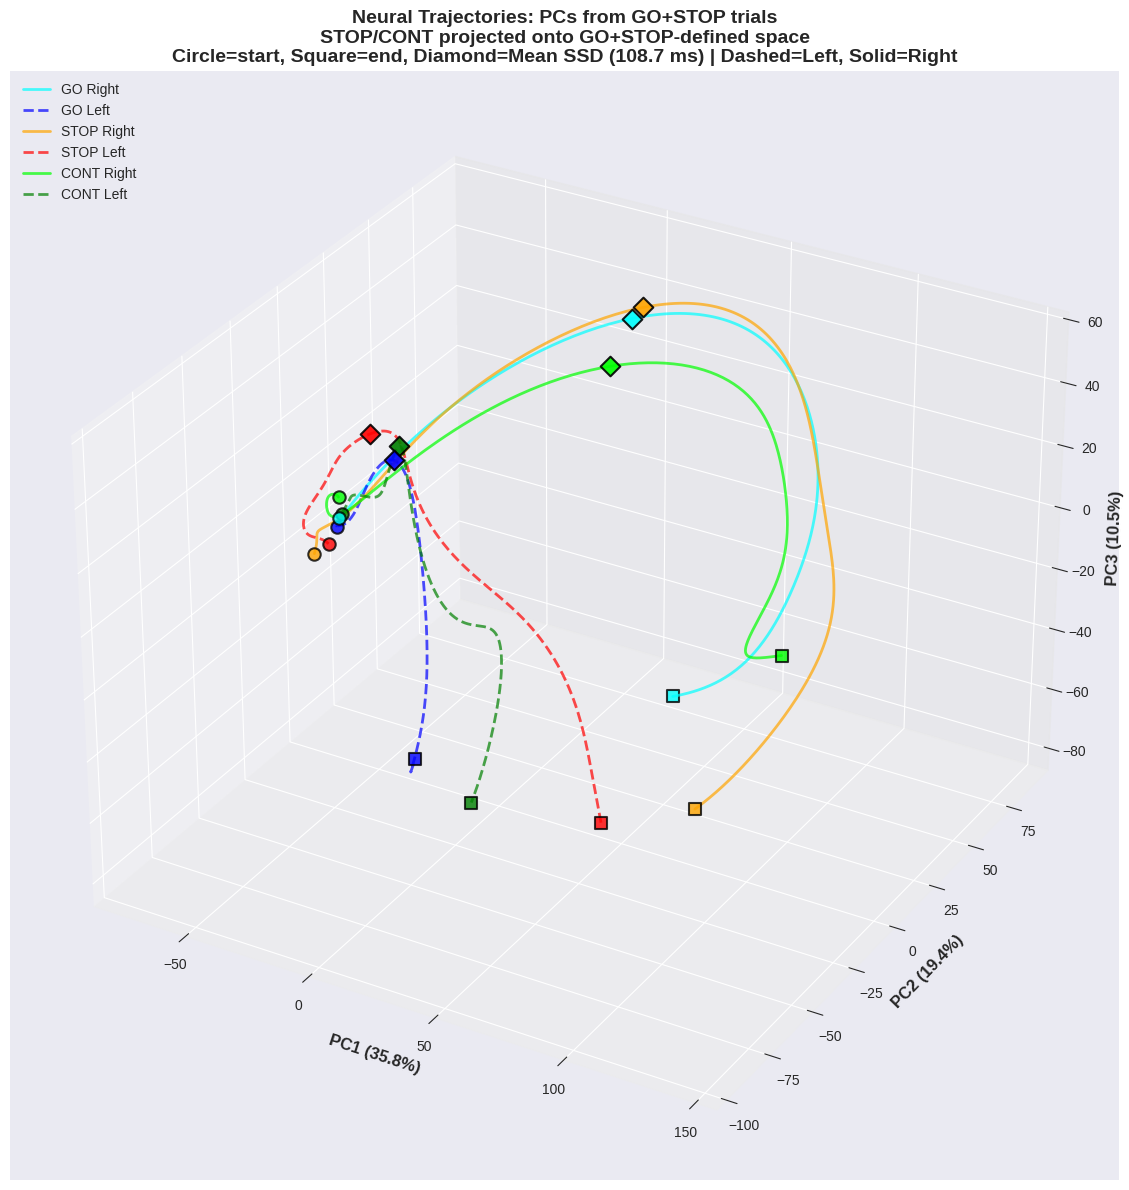

In [8]:
# Visualize in 3D with mean SSD time markers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

# Combine fit and projection trajectories
all_trajectories = {
    'GO_R': (fit_trajectories['GO_R'], 'cyan', 'GO Right', '-'),
    'GO_L': (fit_trajectories['GO_L'], 'blue', 'GO Left', '--'),
    'STOP_R': (projections['STOP_R'], 'orange', 'STOP Right', '-'),
    'STOP_L': (projections['STOP_L'], 'red', 'STOP Left', '--'),
    'CONT_R': (projections['CONT_R'], 'lime', 'CONT Right', '-'),
    'CONT_L': (projections['CONT_L'], 'green', 'CONT Left', '--'),
}

# Create time axes for all conditions
time_axes_ex1 = {}
for spec in fit_specs + proj_specs:
    time_axes_ex1[spec.label] = fpca.get_time_axis(spec)

# Plot trajectories
traj_dict = {}
for key, (traj, color, label, linestyle) in all_trajectories.items():
    traj_dict[key] = traj
    ax.plot(traj[0, :], traj[1, :], traj[2, :],
            label=label, color=color, linewidth=2, alpha=0.7, linestyle=linestyle)
    
    # Mark start and end
    ax.scatter(traj[0, 0], traj[1, 0], traj[2, 0],
              marker='o', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)
    ax.scatter(traj[0, -1], traj[1, -1], traj[2, -1],
              marker='s', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)

# Add mean SSD time markers
add_trajectory_time_marker_3d(ax, traj_dict, time_axes_ex1, mean_ssd_ms,
                              marker_symbol='D', marker_size=100, marker_label='Mean SSD')

# Labels
var_ratios = fpca.pca_model.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_ratios[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({var_ratios[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({var_ratios[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('Neural Trajectories: PCs from GO+STOP trials\nSTOP/CONT projected onto GO+STOP-defined space\n'
             f'Circle=start, Square=end, Diamond=Mean SSD ({mean_ssd_ms:.1f} ms) | Dashed=Left, Solid=Right',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

## 4.1 Visualizations for Example 1

Demonstrate the flexibility with the GO+STOP fit + CONT projection example.

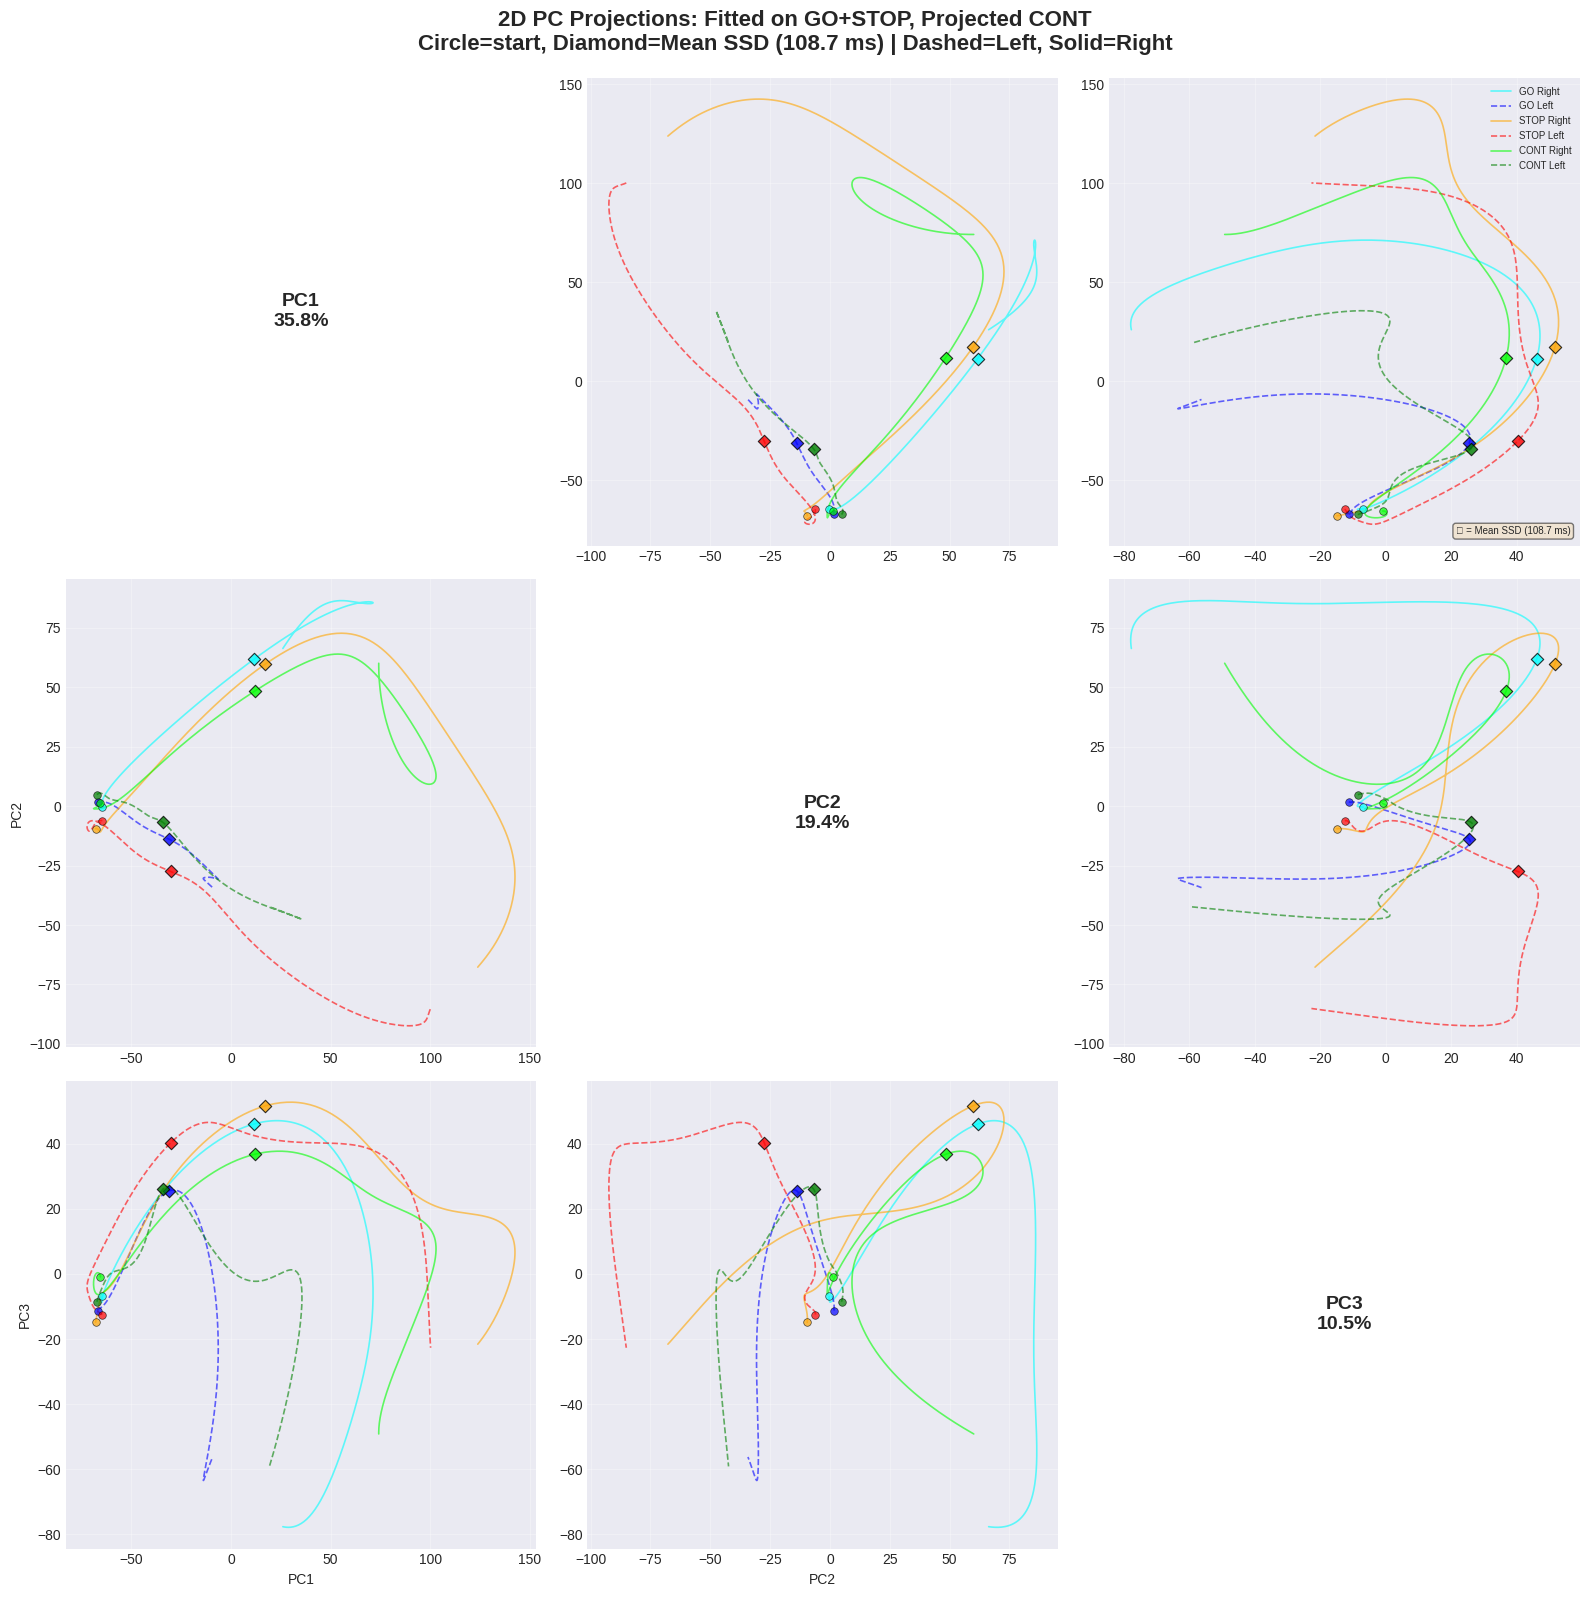

In [9]:
# Combine fit and projection trajectories from Example 1
all_trajectories_ex1 = {}
all_trajectories_ex1.update(fit_trajectories)
all_trajectories_ex1.update(projections)

# 2D projection matrix with mean SSD markers
plot_pca_2d_projections(
    trajectories_dict=all_trajectories_ex1,
    explained_variance_ratio=fpca.pca_model.explained_variance_ratio_,
    n_pcs=3,
    title=f'2D PC Projections: Fitted on GO+STOP, Projected CONT\nCircle=start, Diamond=Mean SSD ({mean_ssd_ms:.1f} ms) | Dashed=Left, Solid=Right',
    time_axes_dict=time_axes_ex1,
    marker_time_ms=mean_ssd_ms,
    marker_label='Mean SSD'
)
plt.show()

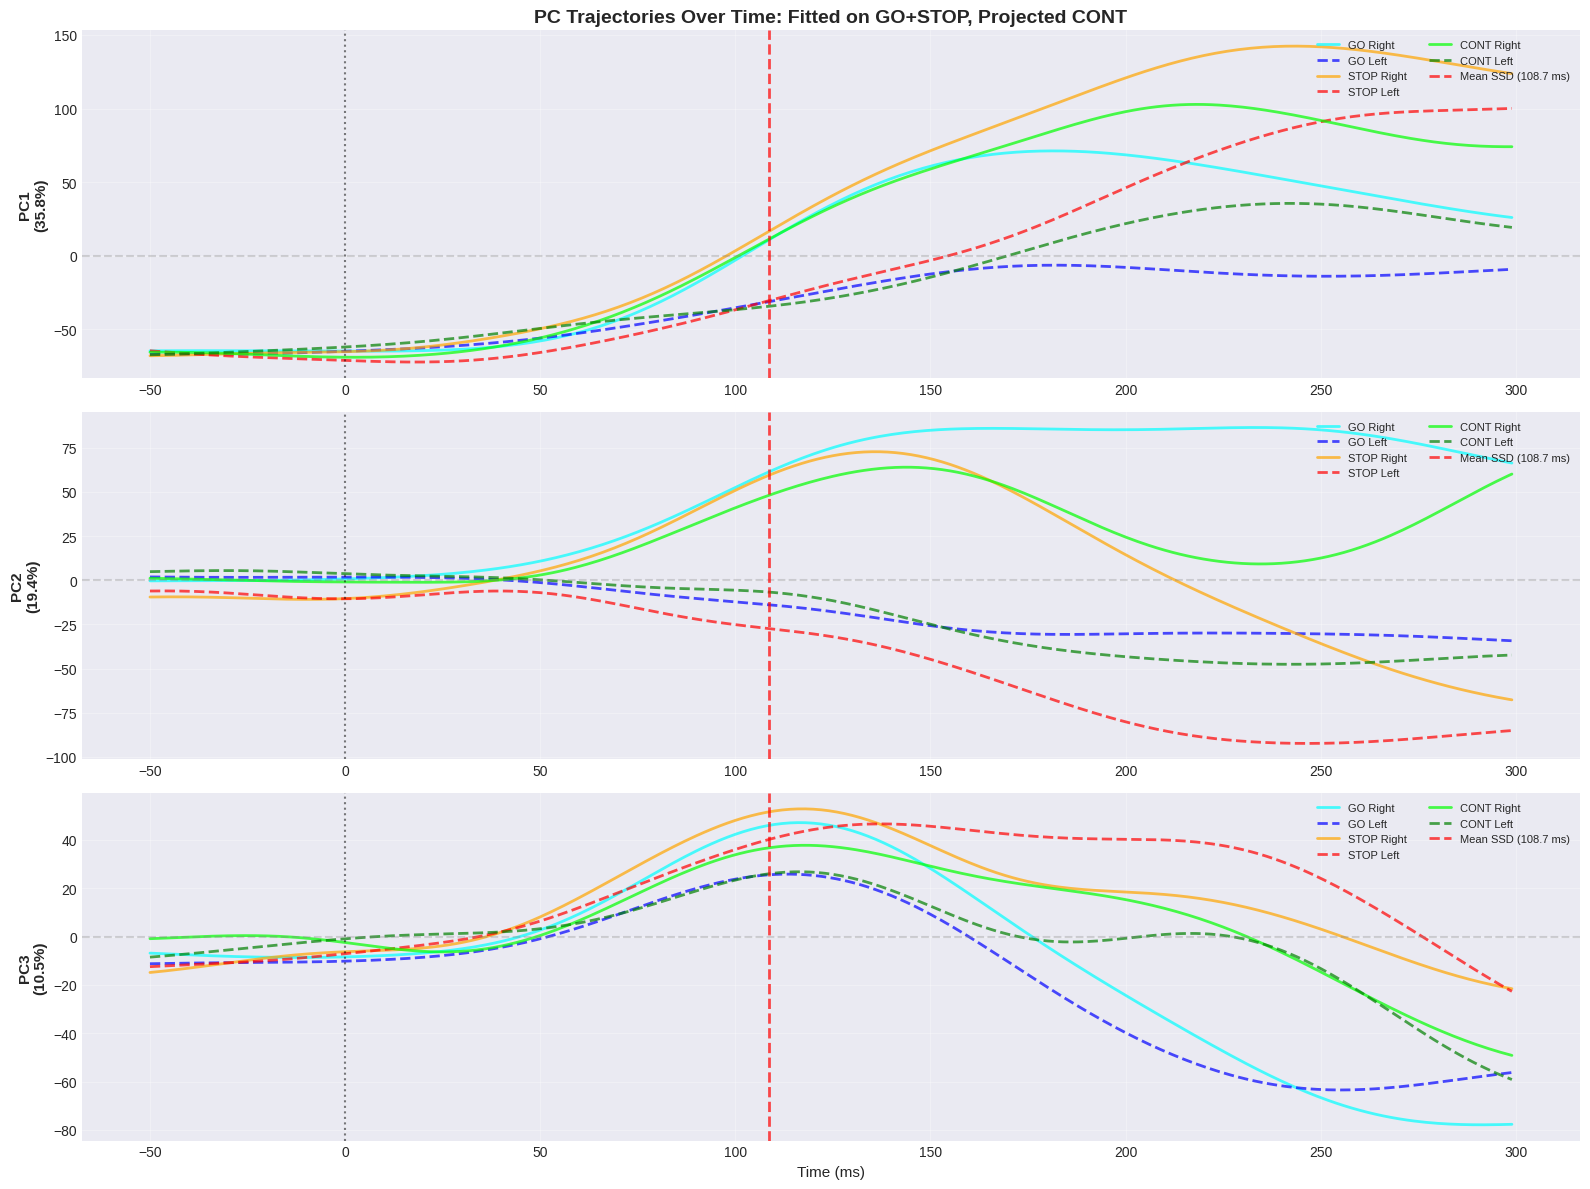

In [10]:
# Plot PC time series with mean SSD vertical line
plot_pca_timeseries(
    trajectories_dict=all_trajectories_ex1,
    time_axes_dict=time_axes_ex1,
    explained_variance_ratio=fpca.pca_model.explained_variance_ratio_,
    n_pcs=3,
    title='PC Trajectories Over Time: Fitted on GO+STOP, Projected CONT',
    marker_time_ms=mean_ssd_ms,
    marker_label='Mean SSD'
)
plt.show()

In [11]:
# Create new PCA instance with parallel processing
fpca2 = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=25,
    n_components=5,
    pca_function=TruncatedSVD,
    verbose=True,
    n_jobs=-1  # Use all CPU cores for parallel processing
)

# Fit on early epoch: -150 to 10 ms (GO trials)
early_specs = [
    TrialSpec('GO', direction=0, epoch=[-150, 10], alignment='go_cue', label='GO_R_early'),
    TrialSpec('GO', direction=180, epoch=[-150, 10], alignment='go_cue', label='GO_L_early'),
]

fpca2.fit(early_specs)


FITTING PCA

Conditions for fitting:
  GO_R_early: epoch [-150, 10] ms, aligned to go_cue
  GO_L_early: epoch [-150, 10] ms, aligned to go_cue

Extracting PSTHs for 1213 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 1213/1213 [00:02<00:00, 585.49it/s]



✓ PSTH extraction complete
  Total neurons processed: 1213
  Neurons with all conditions: 1212
  Neurons excluded (missing conditions): 1
  Data matrix shape: (1212, 320)

Trial counts per condition (neurons with all conditions):
  GO_R_early     : mean=149.6, min=13, max=259
  GO_L_early     : mean=150.2, min=6, max=264

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 6.94 ± 7.68 spikes/sec
  Normalized data: mean=0.000000, std=0.795

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 33.66%
    PC2: 28.49%
    PC3: 14.92%
    PC4: 8.27%
    PC5: 6.64%
  Total variance explained: 91.98%



## 5. Example 2: Fit on early epoch

See how neural activity evolves in PC space defined by an early time window.

In [12]:
# Project later epoch: 100 to 300 ms
late_specs = [
    TrialSpec('GO', direction=0, epoch=[100, 300], alignment='go_cue', label='GO_R_late'),
    TrialSpec('GO', direction=180, epoch=[100, 300], alignment='go_cue', label='GO_L_late'),
]

late_projections = fpca2.project(late_specs)


PROJECTING DATA

Conditions for projection:
  GO_R_late: epoch [100, 300] ms, aligned to go_cue
  GO_L_late: epoch [100, 300] ms, aligned to go_cue

Extracting PSTHs for 1212 neurons...


Processing GO_R_late: 100%|██████████| 1212/1212 [00:01<00:00, 651.67it/s]


  GO_R_late: 1212/1212 neurons have data
  Projection shape: (5, 200)


Processing GO_L_late: 100%|██████████| 1212/1212 [00:01<00:00, 652.15it/s]


  GO_L_late: 1212/1212 neurons have data
  Projection shape: (5, 200)

✓ Projection complete


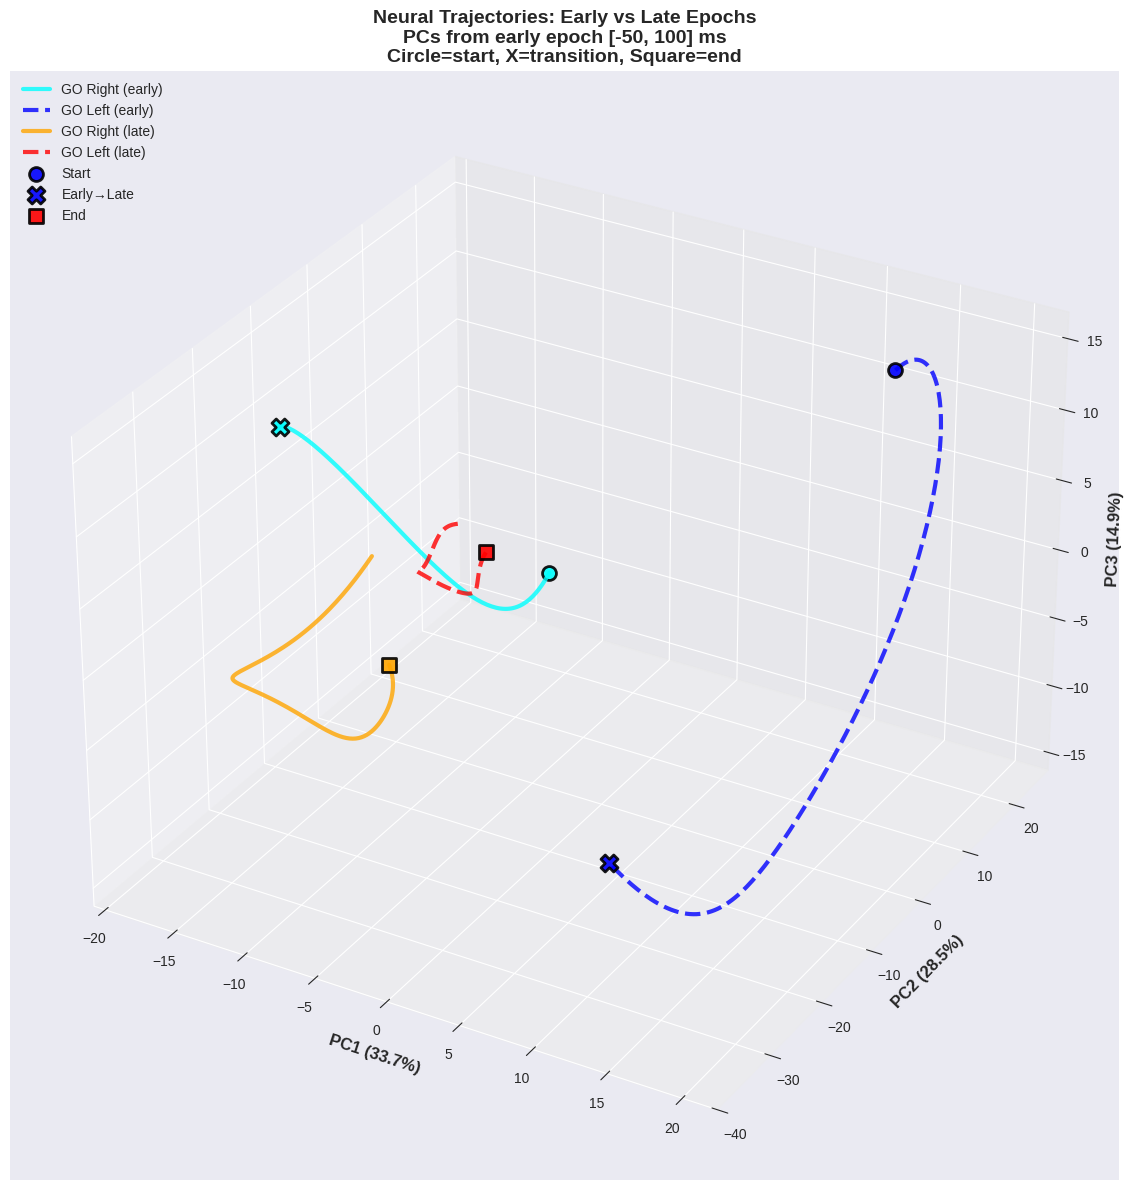

In [13]:
# Visualize early vs late epochs in 3D
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

early_traj = fpca2.get_fit_trajectories()

# Plot early epoch (fit)
ax.plot(early_traj['GO_R_early'][0, :], early_traj['GO_R_early'][1, :], early_traj['GO_R_early'][2, :],
        label='GO Right (early)', color='cyan', linewidth=3, alpha=0.8, linestyle='-')
ax.plot(early_traj['GO_L_early'][0, :], early_traj['GO_L_early'][1, :], early_traj['GO_L_early'][2, :],
        label='GO Left (early)', color='blue', linewidth=3, alpha=0.8, linestyle='--')

# Plot late epoch (projection)
ax.plot(late_projections['GO_R_late'][0, :], late_projections['GO_R_late'][1, :], late_projections['GO_R_late'][2, :],
        label='GO Right (late)', color='orange', linewidth=3, alpha=0.8, linestyle='-')
ax.plot(late_projections['GO_L_late'][0, :], late_projections['GO_L_late'][1, :], late_projections['GO_L_late'][2, :],
        label='GO Left (late)', color='red', linewidth=3, alpha=0.8, linestyle='--')

# Mark transitions
for traj, color in [(early_traj['GO_R_early'], 'cyan'), (early_traj['GO_L_early'], 'blue')]:
    ax.scatter(traj[0, 0], traj[1, 0], traj[2, 0],
              marker='o', s=100, color=color, edgecolors='black', linewidths=2, alpha=0.9, label='Start')
    ax.scatter(traj[0, -1], traj[1, -1], traj[2, -1],
              marker='X', s=150, color=color, edgecolors='black', linewidths=2, alpha=0.9, label='Early→Late')

for traj, color in [(late_projections['GO_R_late'], 'orange'), (late_projections['GO_L_late'], 'red')]:
    ax.scatter(traj[0, -1], traj[1, -1], traj[2, -1],
              marker='s', s=100, color=color, edgecolors='black', linewidths=2, alpha=0.9, label='End')

# Labels
var_ratios = fpca2.pca_model.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_ratios[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({var_ratios[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({var_ratios[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title('Neural Trajectories: Early vs Late Epochs\n'
             'PCs from early epoch [-50, 100] ms\n'
             'Circle=start, X=transition, Square=end',
             fontsize=14, fontweight='bold')

# Remove duplicate labels in legend
handles, labels = ax.get_legend_handles_labels()
unique_labels = dict(zip(labels, handles))
ax.legend(unique_labels.values(), unique_labels.keys(), fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

## 6. Example 3: Standard 6-condition PCA

Quick way to create all 6 standard conditions.

In [14]:
# Create standard specs (all 6 conditions)
standard_specs = create_standard_specs(
    go_epok=[-50, 300],
    stop_epok=[-50, 300],
    cont_epok=[-50, 300],
    go_align='go_cue',
    stop_cont_align='go_cue',
    ssd_number=2,
    include_both_dirs=True
)

print("Standard specs created:")
for spec in standard_specs:
    print(f"  {spec}")

Standard specs created:
  TrialSpec(GO, dir=0, epoch=[-50, 300], align=go_cue, label=GO_R)
  TrialSpec(STOP, dir=0, epoch=[-50, 300], align=go_cue, label=STOP_R)
  TrialSpec(CONT, dir=0, epoch=[-50, 300], align=go_cue, label=CONT_R)
  TrialSpec(GO, dir=180, epoch=[-50, 300], align=go_cue, label=GO_L)
  TrialSpec(STOP, dir=180, epoch=[-50, 300], align=go_cue, label=STOP_L)
  TrialSpec(CONT, dir=180, epoch=[-50, 300], align=go_cue, label=CONT_L)


In [15]:
# Fit on all 6 conditions (recreates condition_concatenated_pca approach)
# Using parallel processing for faster computation
fpca3 = FlexiblePCA(
    cell_df,
    bin_size=1,
    smooth_ker_size=25,
    n_components=5,
    pca_function=TruncatedSVD,
    verbose=True,
    n_jobs=-1  # Use all CPU cores for parallel processing
)

fpca3.fit(standard_specs)


FITTING PCA

Conditions for fitting:
  GO_R: epoch [-50, 300] ms, aligned to go_cue
  STOP_R: epoch [-50, 300] ms, aligned to go_cue
  CONT_R: epoch [-50, 300] ms, aligned to go_cue
  GO_L: epoch [-50, 300] ms, aligned to go_cue
  STOP_L: epoch [-50, 300] ms, aligned to go_cue
  CONT_L: epoch [-50, 300] ms, aligned to go_cue

Extracting PSTHs for 1213 neurons...
  Using 20 parallel workers
  Pre-filtering cell data...


Processing cells: 100%|██████████| 1213/1213 [00:02<00:00, 505.31it/s]



✓ PSTH extraction complete
  Total neurons processed: 1213
  Neurons with all conditions: 1202
  Neurons excluded (missing conditions): 11
  Data matrix shape: (1202, 2100)

Trial counts per condition (neurons with all conditions):
  GO_R           : mean=150.6, min=13, max=259
  STOP_R         : mean=11.5, min=1, max=24
  CONT_R         : mean=13.5, min=1, max=27
  GO_L           : mean=151.3, min=10, max=264
  STOP_L         : mean=10.4, min=1, max=25
  CONT_L         : mean=15.1, min=1, max=30

Normalizing data (centering (mean subtraction) per neuron)...
✓ Normalization complete
  Mean firing rate: 7.25 ± 8.04 spikes/sec
  Normalized data: mean=-0.000000, std=3.662

Fitting TruncatedSVD with 5 components...

✓ PCA fitted
  Explained variance ratios:
    PC1: 26.66%
    PC2: 13.24%
    PC3: 7.08%
    PC4: 5.53%
    PC5: 4.70%
  Total variance explained: 57.21%



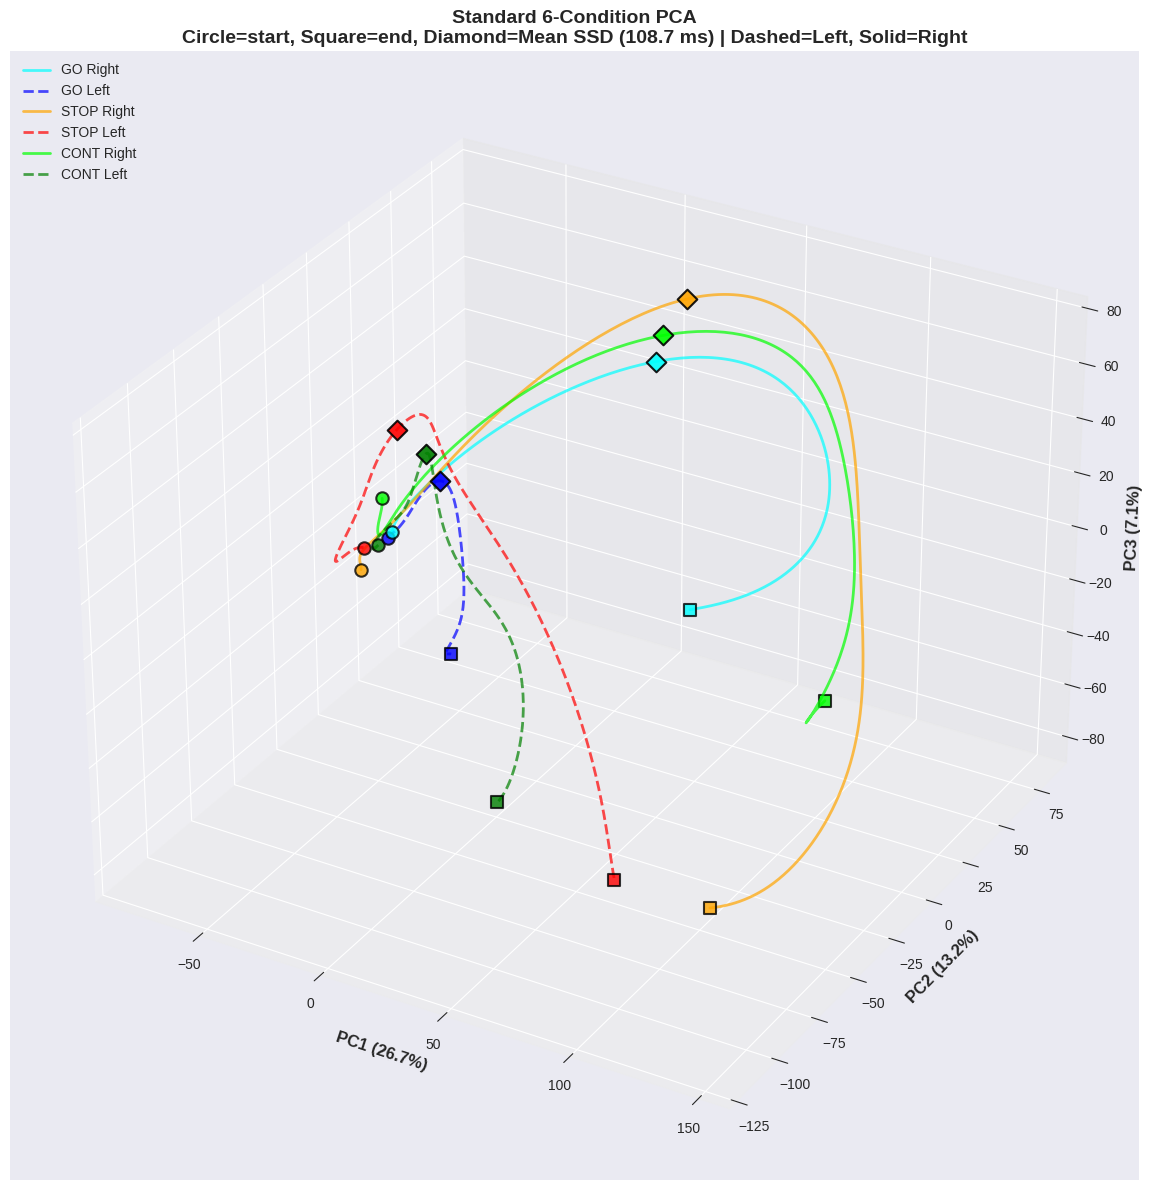

In [16]:
# Get all trajectories
all_traj = fpca3.get_fit_trajectories()

# Create time axes for all standard conditions
time_axes_std = {}
for spec in standard_specs:
    time_axes_std[spec.label] = fpca3.get_time_axis(spec)

# 3D plot with mean SSD time markers
fig = plt.figure(figsize=(16, 12))
ax = fig.add_subplot(111, projection='3d')

plot_config = {
    'GO_R': ('cyan', 'GO Right', '-'),
    'GO_L': ('blue', 'GO Left', '--'),
    'STOP_R': ('orange', 'STOP Right', '-'),
    'STOP_L': ('red', 'STOP Left', '--'),
    'CONT_R': ('lime', 'CONT Right', '-'),
    'CONT_L': ('green', 'CONT Left', '--'),
}

for label, (color, name, linestyle) in plot_config.items():
    traj = all_traj[label]
    ax.plot(traj[0, :], traj[1, :], traj[2, :],
            label=name, color=color, linewidth=2, alpha=0.7, linestyle=linestyle)
    ax.scatter(traj[0, 0], traj[1, 0], traj[2, 0],
              marker='o', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)
    ax.scatter(traj[0, -1], traj[1, -1], traj[2, -1],
              marker='s', s=80, color=color, edgecolors='black', linewidths=1.5, alpha=0.8)

# Add mean SSD time markers
add_trajectory_time_marker_3d(ax, all_traj, time_axes_std, mean_ssd_ms,
                              marker_symbol='D', marker_size=100, marker_label='Mean SSD')

var_ratios = fpca3.pca_model.explained_variance_ratio_
ax.set_xlabel(f'PC1 ({var_ratios[0]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({var_ratios[1]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_zlabel(f'PC3 ({var_ratios[2]*100:.1f}%)', fontsize=12, fontweight='bold')
ax.set_title(f'Standard 6-Condition PCA\nCircle=start, Square=end, Diamond=Mean SSD ({mean_ssd_ms:.1f} ms) | Dashed=Left, Solid=Right',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='upper left')

plt.tight_layout()
plt.show()

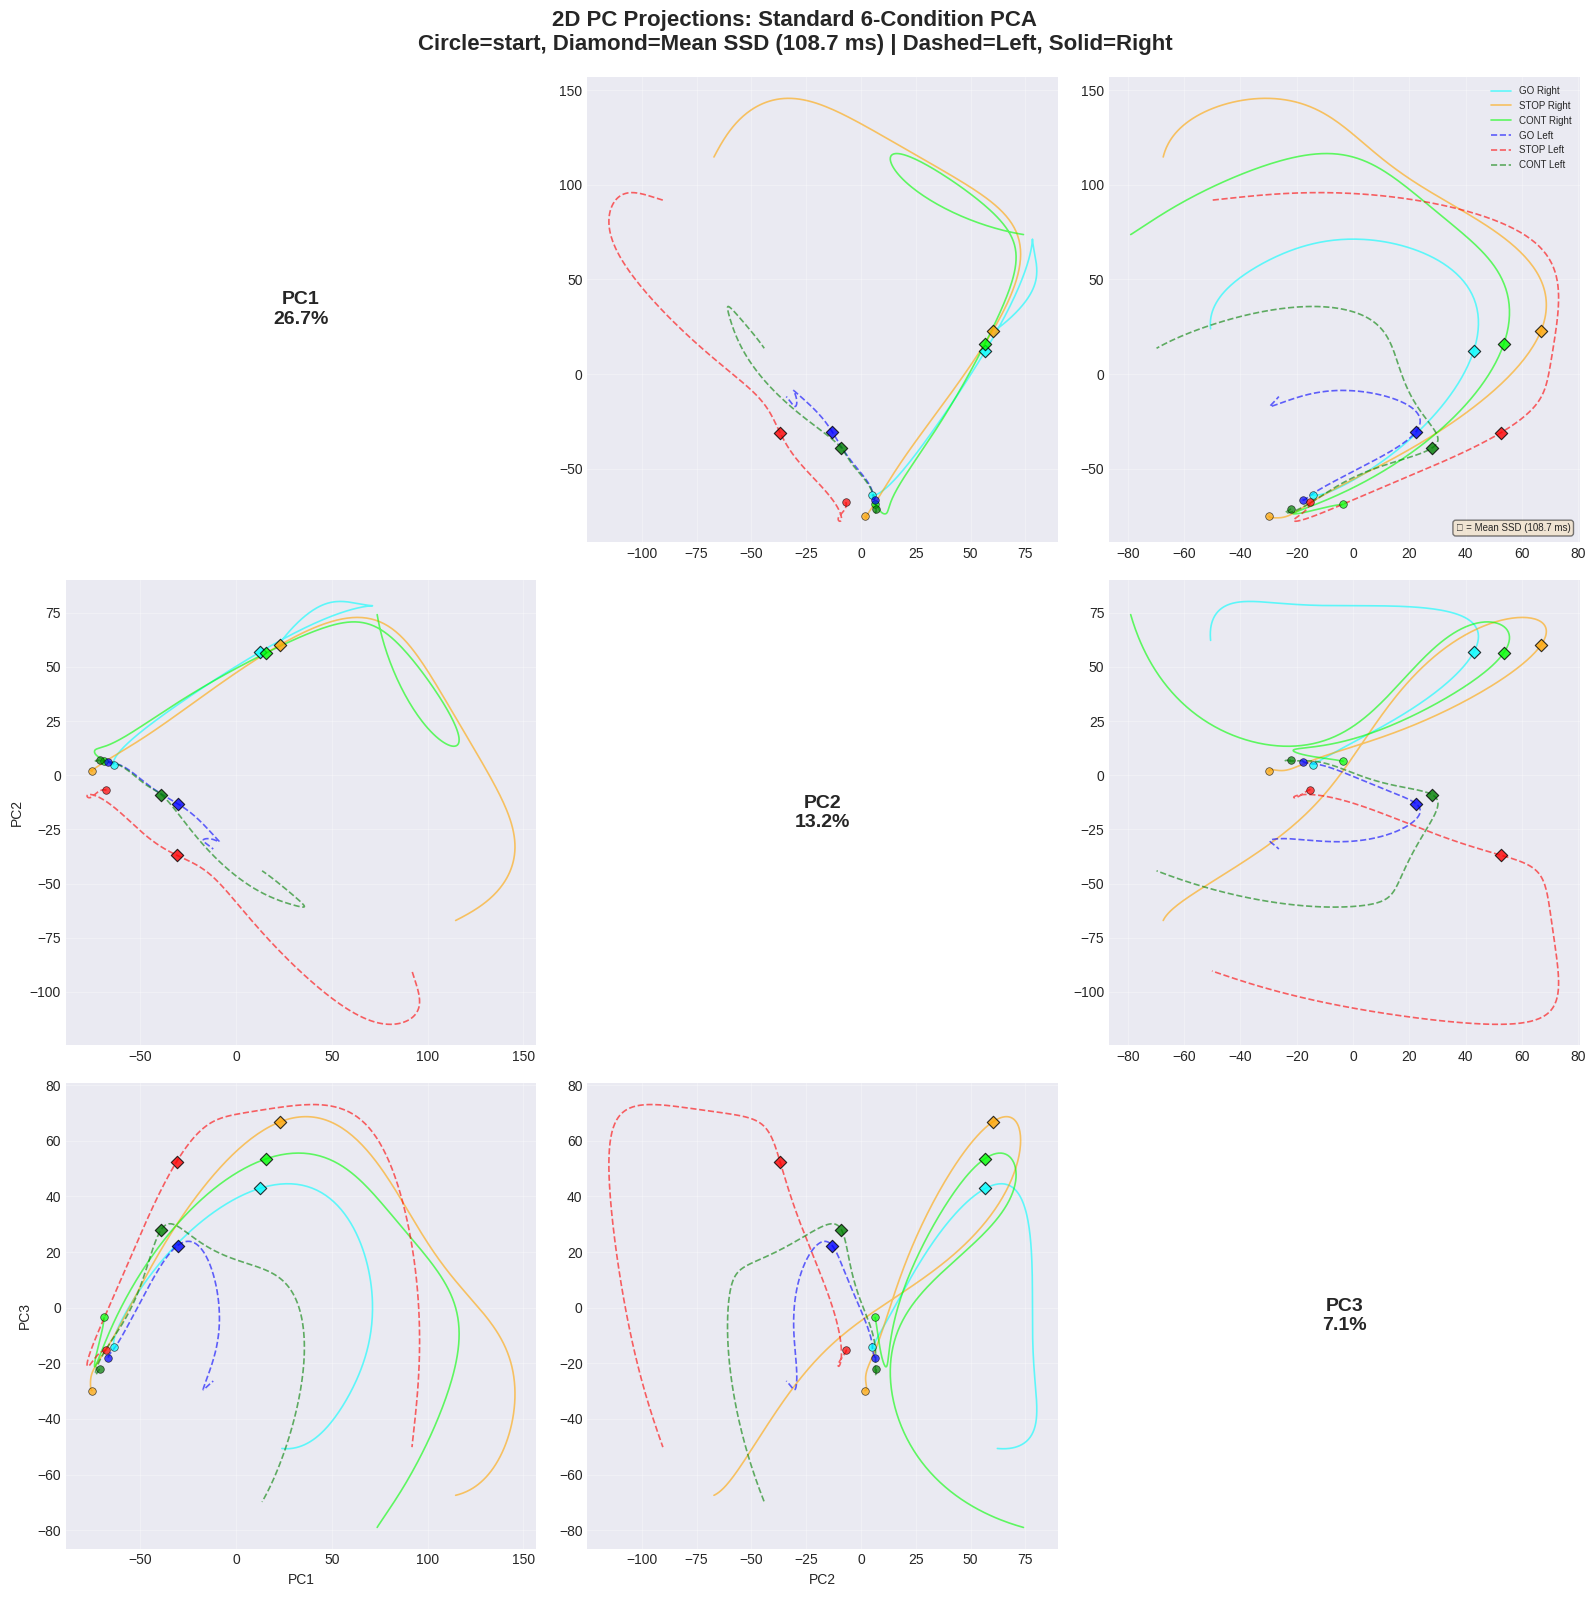

In [17]:
# Create 2D projection matrix for the standard 6-condition PCA with mean SSD markers
plot_pca_2d_projections(
    trajectories_dict=all_traj,
    explained_variance_ratio=fpca3.pca_model.explained_variance_ratio_,
    n_pcs=3,
    title=f'2D PC Projections: Standard 6-Condition PCA\nCircle=start, Diamond=Mean SSD ({mean_ssd_ms:.1f} ms) | Dashed=Left, Solid=Right',
    time_axes_dict=time_axes_std,
    marker_time_ms=mean_ssd_ms,
    marker_label='Mean SSD'
)
plt.show()

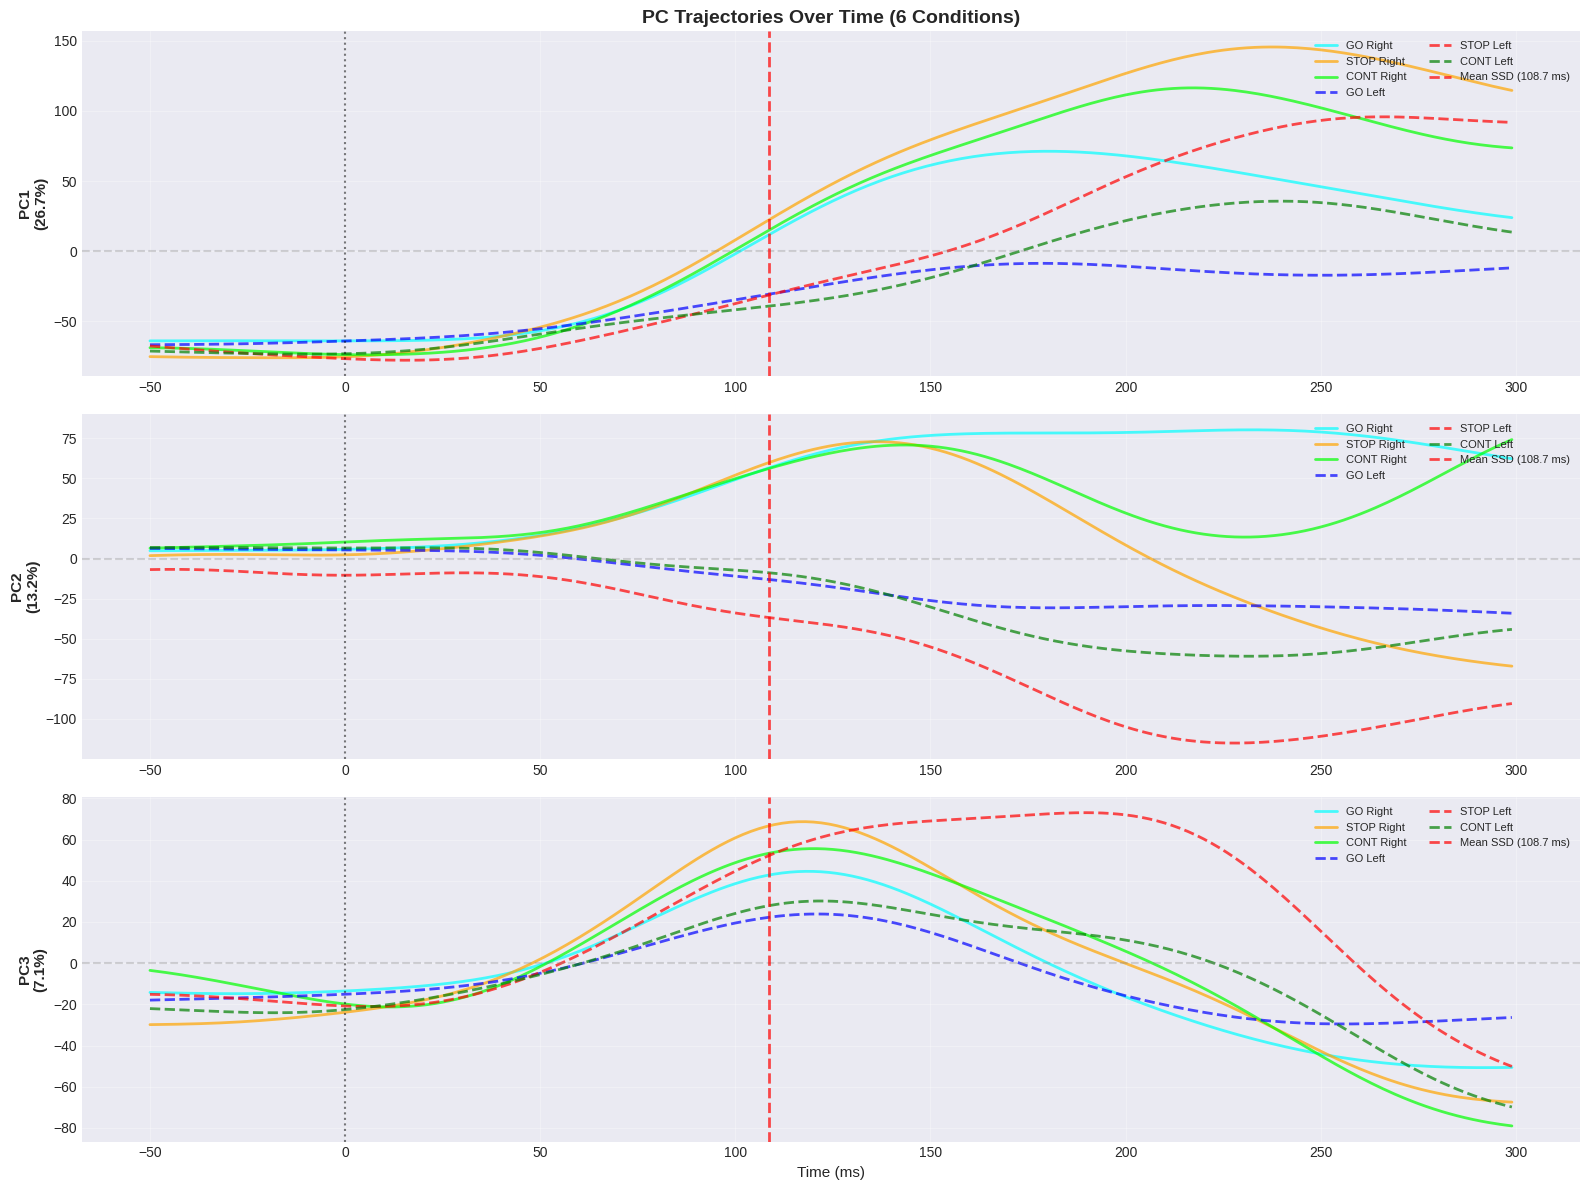

In [18]:
# Plot PC time series with mean SSD vertical line
plot_pca_timeseries(
    trajectories_dict=all_traj,
    time_axes_dict=time_axes_std,
    explained_variance_ratio=fpca3.pca_model.explained_variance_ratio_,
    n_pcs=3,
    title='PC Trajectories Over Time (6 Conditions)',
    marker_time_ms=mean_ssd_ms,
    marker_label='Mean SSD'
)
plt.show()

## 7. Explained Variance Analysis

Visualize how much variance each PC explains and the cumulative variance across PCs.

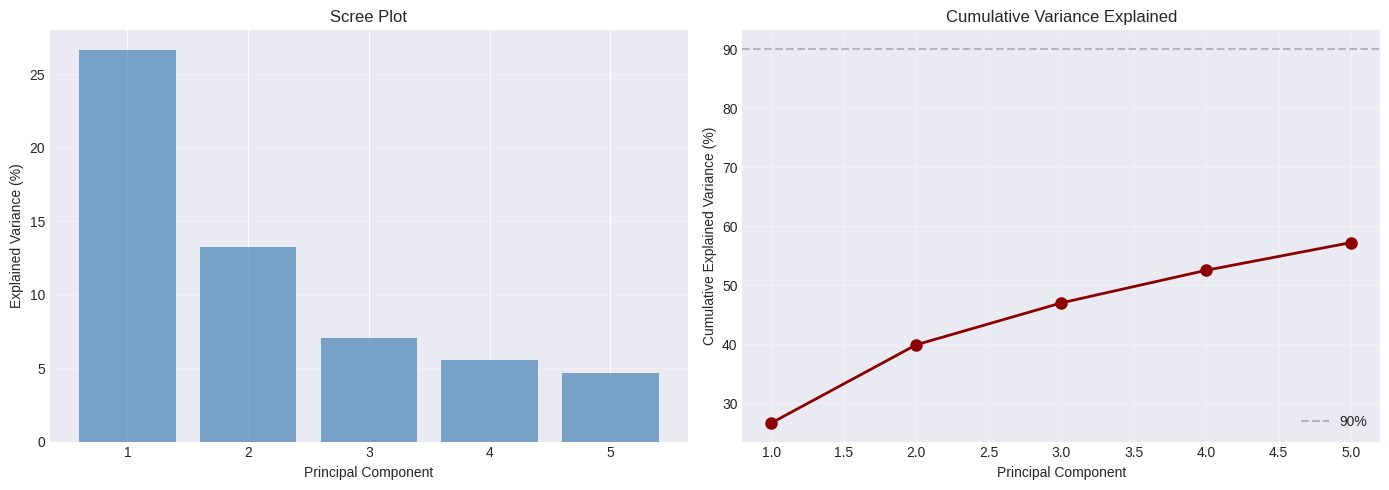


Explained variance by component:
  PC1: 26.66%
  PC2: 13.24%
  PC3: 7.08%
  PC4: 5.53%
  PC5: 4.70%

Total variance explained by 5 components: 57.21%


In [19]:
# Visualize explained variance for the standard 6-condition PCA
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Get explained variance ratio
explained_var = fpca3.pca_model.explained_variance_ratio_
n_components = len(explained_var)

# Scree plot
axes[0].bar(range(1, n_components + 1), 
           explained_var * 100,
           alpha=0.7, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title('Scree Plot')
axes[0].grid(axis='y', alpha=0.3)

# Cumulative variance
cumvar = np.cumsum(explained_var) * 100
axes[1].plot(range(1, n_components + 1), cumvar, 
            marker='o', linewidth=2, markersize=8, color='darkred')
axes[1].axhline(90, color='gray', linestyle='--', alpha=0.5, label='90%')
axes[1].set_xlabel('Principal Component')
axes[1].set_ylabel('Cumulative Explained Variance (%)')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nExplained variance by component:")
for i, var in enumerate(explained_var):
    print(f"  PC{i+1}: {var*100:.2f}%")
print(f"\nTotal variance explained by {n_components} components: {cumvar[-1]:.2f}%")

## 8. Performance Notes

The `n_jobs` parameter controls parallel processing during **both fit() and project()** operations:
- `n_jobs=1`: Sequential processing (default, slower but more debuggable)
- `n_jobs=-1`: Use all CPU cores (faster, recommended for production)
- `n_jobs=N`: Use N specific cores

### Expected Performance (1213 neurons, 6 conditions)

**Sequential (n_jobs=1)**:
- fit(): ~28-36 seconds
- project(): ~35-45 seconds per 6 conditions

**Parallel (n_jobs=-1 on 20-core system)**:
- fit(): ~4-6 seconds (5-7x speedup!)
- project(): ~5-8 seconds per 6 conditions (5-7x speedup!)

The parallelization provides significant speedup for both operations, especially with large datasets.

## 9. Normalization Notes

The `z_score` parameter controls how data is normalized:

**z_score=True**:
- Subtracts mean AND divides by std (full z-scoring)
- Each neuron's activity is scaled to have mean=0, std=1
- Recommended for most analyses

**z_score=False (default)**:
- Only subtracts mean (centering)
- Each neuron's activity has mean=0 but preserves original variance
- Useful when you want to preserve relative firing rate differences

Both options use **vectorized numpy operations** for fast computation (no for loops!).

## 10. Summary

The **FlexiblePCA** class provides:

1. **Flexible fitting**: Define arbitrary trial conditions for PCA fitting
2. **Flexible projection**: Project different conditions onto fitted PCs
3. **Easy specification**: `TrialSpec` objects make it clear what you're analyzing
4. **Helper functions**: `create_standard_specs()` for common use cases
5. **Time axis management**: `get_time_axis()` for plotting
6. **Comprehensive visualization**: 3D trajectories, 2D projection matrices, PC time series, and explained variance plots
7. **Time markers**: Add markers at specific time points (e.g., mean SSD time) to all plot types
8. **Variance analysis**: Scree plots and cumulative variance plots to understand PC importance

### Key advantages over fixed approaches:

- Can fit on any subset of conditions
- Can project any conditions (even different epochs/alignments)
- Reuse fitted PCA for multiple projections
- Compare how different conditions use the same neural space
- Investigate temporal evolution in fixed PC space
- Unified plotting functions eliminate code duplication
- Mark important time points (like mean SSD) across all visualizations
- Visualize explained variance to understand PC contributions